In [2]:
import sys
sys.executable

'c:\\kalpesh\\1.ITvedant\\2.ML projects\\Silage_Sales_ML_Project\\venv\\Scripts\\python.exe'

In [5]:
import pandas as pd
from sqlalchemy import create_engine

In [6]:
username = "root"
password = "root"
host = "localhost"
port = "3306"
database = "Pancham_Silage_Factory_DB"

engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")

In [7]:
engine.connect()

In [8]:
version = sys.version
print(version)

3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]


# Smart Silage Pricing Model

### 1. Introduction

#### Project Objective

The objective of this machine learning project is to analyze and predict the **price per metric ton of silage crops** using historical agricultural trading data. 

The model examines key factors such as **crop type, harvest season, moisture content, packaging type, customer segment, and order quantity** to understand how these variables influence pricing and sales outcomes.

By applying machine learning techniques, the system aims to support **data-driven decision making in agricultural supply chains**, helping businesses optimize pricing strategies, manage logistics costs, and improve overall profitability.

## 1. Importing essential python libraries 

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

import warnings
warnings.filterwarnings('ignore')

## 2. Dataset Loading

In [10]:
df = pd.read_sql("SELECT * FROM main_data", engine)
df.head()

,Transaction_ID,Date,Customer_Type,Crop_Type,Harvest_Season,Moisture_Content_Percent,DM_Content_Percent,Quantity_MT,Price_per_MT_INR,Total_Sales_INR,Logistics_Cost_INR,Profit_Margin_Percent,Payment_Mode,Credit_Period_Days,Bagging_Type
0,TXN2022-000077,2022-07-08,Co-operative,Maize,Kharif,69.1,30.9,9.37,6284.0,61682.71,2239.89,18.25,UPI,0,Bulk
1,TXN2022-000092,2022-09-28,Individual Farmer,Bajra,Kharif,67.4,32.6,8.23,7608.0,63157.02,3187.47,20.25,Credit,14,Bulk
2,TXN2022-000126,2022-12-06,Individual Farmer,Maize,Rabi,64.8,35.2,12.16,6885.0,91200.00,2247.52,10.59,Bank Transfer,0,Bags
3,TXN2022-000128,2022-12-06,Dairy Farm,Bajra,Rabi,59.1,40.9,3.43,6664.0,28088.27,3597.29,13.38,Credit,21,Bale-50kg
4,TXN2022-000133,2022-06-11,Individual Farmer,Jowar,Summer,68.4,31.6,5.69,8161.0,51966.77,2222.68,20.54,Bank Transfer,0,Bale-50kg


## 3. Data Cleaning & Preprocessing

In [11]:
df.info()
df.isnull().sum()
df.columns = df.columns.str.strip()
df.columns = df.columns.str.title()
df.fillna('0',inplace=True)
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4759 entries, 0 to 4758
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Transaction_ID            4759 non-null   object 
 1   Date                      4759 non-null   object 
 2   Customer_Type             4759 non-null   object 
 3   Crop_Type                 4759 non-null   object 
 4   Harvest_Season            4759 non-null   object 
 5   Moisture_Content_Percent  4759 non-null   float64
 6   DM_Content_Percent        4759 non-null   float64
 7   Quantity_MT               4759 non-null   float64
 8   Price_per_MT_INR          4759 non-null   float64
 9   Total_Sales_INR           4759 non-null   float64
 10  Logistics_Cost_INR        4759 non-null   float64
 11  Profit_Margin_Percent     4759 non-null   float64
 12  Payment_Mode              4759 non-null   object 
 13  Credit_Period_Days        4759 non-null   int64  
 14  Bagging_

,Transaction_Id,Date,Customer_Type,Crop_Type,Harvest_Season,Moisture_Content_Percent,Dm_Content_Percent,Quantity_Mt,Price_Per_Mt_Inr,Total_Sales_Inr,Logistics_Cost_Inr,Profit_Margin_Percent,Payment_Mode,Credit_Period_Days,Bagging_Type
0,TXN2022-000077,2022-07-08,Co-operative,Maize,Kharif,69.1,30.9,9.37,6284.0,61682.71,2239.89,18.25,UPI,0,Bulk
1,TXN2022-000092,2022-09-28,Individual Farmer,Bajra,Kharif,67.4,32.6,8.23,7608.0,63157.02,3187.47,20.25,Credit,14,Bulk
2,TXN2022-000126,2022-12-06,Individual Farmer,Maize,Rabi,64.8,35.2,12.16,6885.0,91200.00,2247.52,10.59,Bank Transfer,0,Bags
3,TXN2022-000128,2022-12-06,Dairy Farm,Bajra,Rabi,59.1,40.9,3.43,6664.0,28088.27,3597.29,13.38,Credit,21,Bale-50kg
4,TXN2022-000133,2022-06-11,Individual Farmer,Jowar,Summer,68.4,31.6,5.69,8161.0,51966.77,2222.68,20.54,Bank Transfer,0,Bale-50kg


In [12]:
df.columns

Index(['Transaction_Id', 'Date', 'Customer_Type', 'Crop_Type',
       'Harvest_Season', 'Moisture_Content_Percent', 'Dm_Content_Percent',
       'Quantity_Mt', 'Price_Per_Mt_Inr', 'Total_Sales_Inr',
       'Logistics_Cost_Inr', 'Profit_Margin_Percent', 'Payment_Mode',
       'Credit_Period_Days', 'Bagging_Type'],
      dtype='object')

In [13]:
df.drop(columns=['Transaction_Id', 'Date', 'Dm_Content_Percent'], inplace=True)

In [14]:
df.head()

,Customer_Type,Crop_Type,Harvest_Season,Moisture_Content_Percent,Quantity_Mt,Price_Per_Mt_Inr,Total_Sales_Inr,Logistics_Cost_Inr,Profit_Margin_Percent,Payment_Mode,Credit_Period_Days,Bagging_Type
0,Co-operative,Maize,Kharif,69.1,9.37,6284.0,61682.71,2239.89,18.25,UPI,0,Bulk
1,Individual Farmer,Bajra,Kharif,67.4,8.23,7608.0,63157.02,3187.47,20.25,Credit,14,Bulk
2,Individual Farmer,Maize,Rabi,64.8,12.16,6885.0,91200.00,2247.52,10.59,Bank Transfer,0,Bags
3,Dairy Farm,Bajra,Rabi,59.1,3.43,6664.0,28088.27,3597.29,13.38,Credit,21,Bale-50kg
4,Individual Farmer,Jowar,Summer,68.4,5.69,8161.0,51966.77,2222.68,20.54,Bank Transfer,0,Bale-50kg


## 4.Feature Engineering`

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4759 entries, 0 to 4758
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_Type             4759 non-null   object 
 1   Crop_Type                 4759 non-null   object 
 2   Harvest_Season            4759 non-null   object 
 3   Moisture_Content_Percent  4759 non-null   float64
 4   Quantity_Mt               4759 non-null   float64
 5   Price_Per_Mt_Inr          4759 non-null   float64
 6   Total_Sales_Inr           4759 non-null   float64
 7   Logistics_Cost_Inr        4759 non-null   float64
 8   Profit_Margin_Percent     4759 non-null   float64
 9   Payment_Mode              4759 non-null   object 
 10  Credit_Period_Days        4759 non-null   int64  
 11  Bagging_Type              4759 non-null   object 
dtypes: float64(6), int64(1), object(5)
memory usage: 446.3+ KB


In [16]:
def classify_quality(row):

    moisture = row["Moisture_Content_Percent"]

    # Ideal silage ranges
    if 62 <= moisture <= 68:
        return "High Quality Silage"

    else:
        return "Average Quality Silage"


df["Silage_Quality"] = df.apply(classify_quality, axis=1)



def quantity_discount(q):
    if q < 5:
        return 0.025
    elif q < 10:
        return 0.05
    elif q < 25:
        return 0.10
    else:
        return 0.15

df["Discount_rate"] = df["Quantity_Mt"].apply(quantity_discount).astype(float)




df.columns

Index(['Customer_Type', 'Crop_Type', 'Harvest_Season',
       'Moisture_Content_Percent', 'Quantity_Mt', 'Price_Per_Mt_Inr',
       'Total_Sales_Inr', 'Logistics_Cost_Inr', 'Profit_Margin_Percent',
       'Payment_Mode', 'Credit_Period_Days', 'Bagging_Type', 'Silage_Quality',
       'Discount_rate'],
      dtype='object')

In [17]:
num_cols = ['Discount_rate']

cat_cols = ['Customer_Type', 'Crop_Type', 'Harvest_Season', 'Bagging_Type', 'Silage_Quality']

target = 'Price_Per_Mt_Inr'


In [18]:
from sklearn.model_selection import train_test_split

x = df[num_cols + cat_cols]

y = df[target]

xtrain, xtest, ytrain, ytest = train_test_split(x,y,test_size=0.3,random_state=42)

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.impute import SimpleImputer

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, num_cols),
        ("cat", cat_pipeline, cat_cols)
    ]
)
remainder="drop"


In [20]:
xctrain_processed = preprocessor.fit_transform(xtrain)
xctest_processed = preprocessor.transform(xtest)

# CLASSIFICATION MODELS (post performance category)

#### Model Training, Model Evaluation & Model Training

In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_reg_model(model, xtest, ytest, name):

    # Predictions
    preds = model.predict(xtest)

    # Metrics
    mae = mean_absolute_error(ytest, preds)
    rmse = np.sqrt(mean_squared_error(ytest, preds))
    r2 = r2_score(ytest, preds)

    # Return metrics
    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

### Gradient Boosting Regressor

In [22]:
from sklearn.ensemble import GradientBoostingRegressor

gb_pipe = Pipeline([
    ("preprocessing", preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        subsample=0.8,
        random_state=42
    ))
])

best_gb = gb_pipe.fit(xtrain, ytrain)

evaluate_reg_model(best_gb, xtest, ytest, "Gradient Boosting")

{'Model': 'Gradient Boosting',
 'MAE': 86.36328187365869,
 'RMSE': 127.61169367639134,
 'R2': 0.9690645168331579}

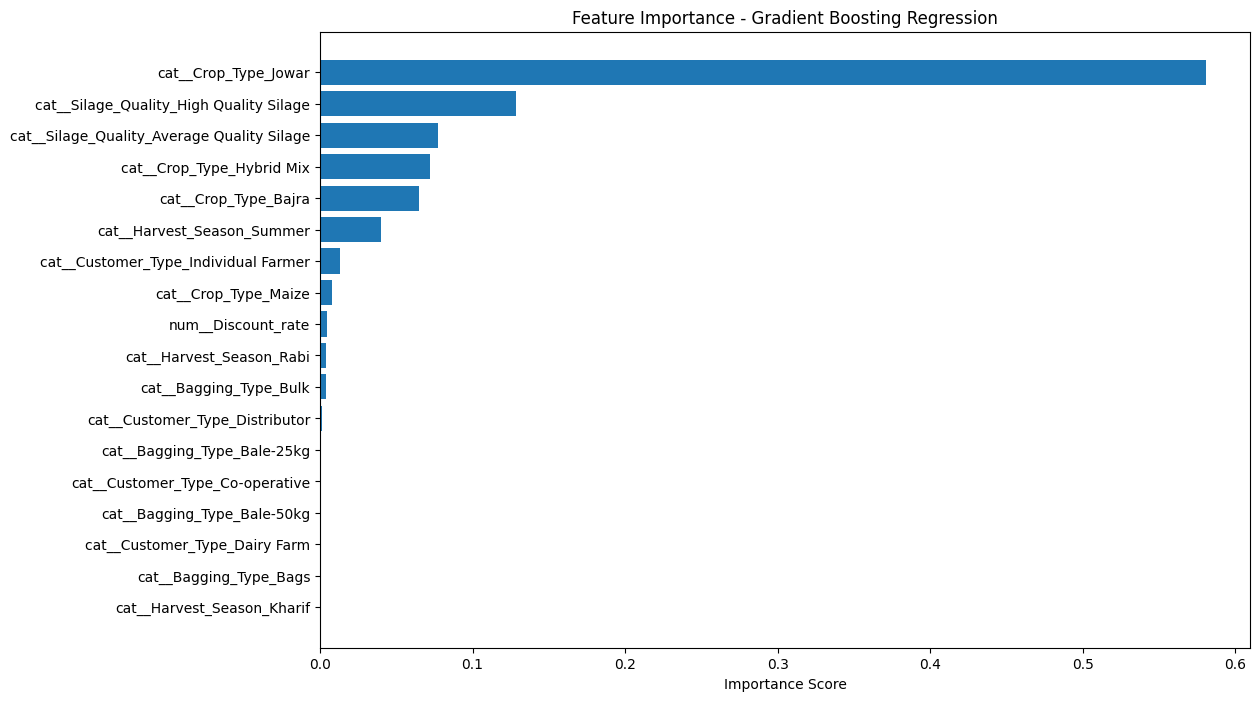

In [23]:
# Use Gradient Boosting model
best_model = best_gb

gb_model = best_model.named_steps["model"]
preprocessor = best_model.named_steps["preprocessing"]

importance = gb_model.feature_importances_
feature_names = preprocessor.get_feature_names_out()

indices = np.argsort(importance)

plt.figure(figsize=(12,8))
plt.barh(range(len(indices)), importance[indices])
plt.yticks(range(len(indices)), feature_names[indices])
plt.title("Feature Importance - Gradient Boosting Regression")
plt.xlabel("Importance Score")
plt.show()

# Deployment 

In [24]:
EXPECTED_COLUMNS = xtrain.columns.tolist()

def safe_input(df):
    for col in EXPECTED_COLUMNS:
        if col not in df:
            df[col] = None
    return df[EXPECTED_COLUMNS]

In [25]:
import pandas as pd

user_input = pd.DataFrame([{
    "Customer_Type": "Dairy Farm",
    "Crop_Type": "Jowar",
    "Harvest_Season": "Rabi",
    "Moisture_Content_%": 63,
    "DM_Content_%": 37,
    "Quantity_MT": 30,
    "Bagging_Type": "Bags",
    "Quality": "Good"
}])

# Apply same preprocessing as training pipeline
user_input = safe_input(user_input)

prediction = best_model.predict(user_input)

print("Predicted Price per MT:", prediction[0])

Predicted Price per MT: 7952.28482961991


# Saving the model for deployment 

In [26]:
import os, joblib

print(os.getcwd())
os.makedirs("models", exist_ok=True)
joblib.dump(best_model, "best_model_pipeline.joblib")
print(os.listdir("models"))

c:\kalpesh\1.ITvedant\2.ML projects\Silage_Sales_ML_Project
['best_model_pipeline.joblib']


In [27]:
import sklearn
print(sklearn.__version__)

1.4.2


In [28]:
import sys
print(sys.version)

3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]


In [29]:
import sys, sklearn, joblib

print(sys.version)
print(sklearn.__version__)

joblib.dump(best_model, "best_model_pipeline.joblib")


3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]
1.4.2


['best_model_pipeline.joblib']